# Notebook 01 — EDA & Feature Engineering
## Airbnb Multi-City Nightly Price Prediction

**Module:** ITI113 Machine Learning & Operations
**Pipeline stage:** 1. Data Storage → 2. Preprocessing
**Task type:** Supervised **regression** — predict nightly listing price (continuous)
**Estimated runtime:** 8–12 minutes on `ml.t3.medium`

---

## Business problem

Airbnb hosts set their own nightly price with almost no guidance. Under-pricing
loses revenue on every booked night; over-pricing loses the booking entirely.
We are building a **host pricing-guidance model**: given the observable
attributes of a listing, estimate the nightly price that comparable listings in
the same micro-market command.

This is deliberately a *decision-support* model, not an automated pricing
engine. That framing drives several choices later — most importantly, that we
optimise for **interpretable, well-calibrated per-segment error** rather than
squeezing the last point of global R².

## What this notebook does

1. Loads the 10-city `Listings.csv` snapshot and stores the raw copy in S3 (pipeline stage 1)
2. Assesses **dataset suitability** against explicit modelling criteria
3. Runs deep EDA — the currency trap, MNAR missingness, sentinel values,
   a Simpson's-paradox reversal in geography, a regulatory fingerprint in New York,
   and the near-orthogonality of review scores to price
4. Cleans and transforms: sentinels, impossible records, per-city outlier trimming
5. Engineers **76 features** with explicit logical / mathematical justification
6. Splits **grouped by `host_id`** to prevent host-level leakage, and quantifies
   how much leakage a naive random split would have introduced
7. Writes processed train/test artefacts back to S3 for Notebook 02

## Prerequisites

- SageMaker Studio, kernel **Python 3 (Data Science 3.0)**, instance `ml.t3.medium`
- SageMaker execution role has S3 read/write on the team prefix
- `Listings.csv` available locally (uploaded to Studio) **or** already in S3

## 0. Configuration

Every downstream cell references these variables. Change them here only.

In [1]:
%pip install -U boto3 botocore mlflow sagemaker-mlflow

  Using cached boto3-1.43.68-py3-none-any.whl.metadata (6.6 kB)


  Using cached botocore-1.43.68-py3-none-any.whl.metadata (5.6 kB)
  Using cached mlflow-3.15.1-py3-none-any.whl.metadata (49 kB)


  Using cached s3transfer-0.19.2-py3-none-any.whl.metadata (1.7 kB)


  Using cached mlflow_skinny-3.15.1-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.15.1-py3-none-any.whl.metadata (19 kB)


  Using cached prettytable-3.18.0-py3-none-any.whl.metadata (37 kB)


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━ 6/7 [mlflow]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━ 6/7 [mlflow]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━ 6/7 [mlflow]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [mlflow]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
aiobotocore 3.7.0 requires botocore<1.43.1,>=1.42.90, but you have botocore 1.43.68 which is incompatible.
autogluon-common 1.5.0 requires pyarrow<21.0.0,>=7.0.0, but you have pyarrow 21.0.0 which is incompatible.
autogluon-multimodal 1.5.0 requires fsspec[http]<=2025.3, but you have fsspec 2026.6.0 which is incompatible.
sagemaker-studio-analytics-extension 0.3.0 requires sparkmagic==0.22.0, but you have sparkmagic 0.21.0 whi

Note: you may need to restart the kernel to use updated packages.


In [14]:
import os, io, ast, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# ------------------------------------------------------------------
# Team / student identity  (house convention — keep consistent 01→03)
# ------------------------------------------------------------------
TEAM_ID      = "team14"
STUDENT_ID   = "s1402"
COURSE       = "ITI113"
SEMESTER     = "26S1"
PROJECT_NAME = "airbnb"

BUCKET = "nyp-26s1-iti113"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"

# ------------------------------------------------------------------
# Modelling contract
# ------------------------------------------------------------------
TARGET        = "log_price_usd"       # we model log price, not raw price (§2.3)
RAW_TARGET    = "price_usd"
GROUP_COLUMN  = "host_id"             # split unit — NOT the row (§5)
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
SNAPSHOT_DATE = "2021-03-01"          # data vintage — see §1.2

# Local path to the raw file inside Studio. Adjust if you uploaded elsewhere.
LOCAL_RAW = "Listings.csv"

# ------------------------------------------------------------------
# AWS is optional in this notebook. If boto3/sagemaker are unavailable
# (e.g. running locally), we degrade gracefully and write to ./artifacts.
# ------------------------------------------------------------------
AWS_AVAILABLE = False
try:
    import boto3, sagemaker
    session = sagemaker.Session()
    role    = sagemaker.get_execution_role()
    region  = boto3.Session().region_name
    s3      = boto3.client("s3")
    AWS_AVAILABLE = True
except Exception as e:
    print(f"[INFO] AWS/SageMaker not available ({type(e).__name__}). "
          f"Running in LOCAL mode; artefacts go to ./artifacts/")
    region, role = "local", "local"

LOCAL_ARTIFACTS = Path("artifacts"); LOCAL_ARTIFACTS.mkdir(exist_ok=True)

print("=" * 72)
print(f"{COURSE} {SEMESTER} — Notebook 01 — EDA & Feature Engineering")
print("=" * 72)
print(f"Team / Student : {TEAM_ID} / {STUDENT_ID}")
print(f"Project        : {PROJECT_NAME}  (regression on nightly price)")
print(f"Bucket / Prefix: s3://{BUCKET}/{PREFIX}")
print(f"Region / Role  : {region} / {str(role).split('/')[-1]}")
print(f"AWS mode       : {'SageMaker' if AWS_AVAILABLE else 'LOCAL fallback'}")
print("=" * 72)

[INFO] AWS/SageMaker not available (AttributeError). Running in LOCAL mode; artefacts go to ./artifacts/
ITI113 26S1 — Notebook 01 — EDA & Feature Engineering
Team / Student : team14 / s1402
Project        : airbnb  (regression on nightly price)
Bucket / Prefix: s3://nyp-26s1-iti113/iti113/team14/data/airbnb
Region / Role  : local / local
AWS mode       : LOCAL fallback


## 1. Load Data and Assess Suitability

### 1.1 Load

The file ships as Latin-1 (not UTF-8) — listing titles contain mojibake such as
`39 mÂ² Paris (Sacre CÅ"ur)`. Reading it as UTF-8 raises a decode error, and
reading it with the wrong encoding silently corrupts every accented
neighbourhood name. We set the encoding explicitly and keep the raw bytes
untouched in S3 so the decision is reversible.

In [15]:
t0 = time.time()

if Path(LOCAL_RAW).exists():
    df_raw = pd.read_csv(LOCAL_RAW, encoding="latin-1", low_memory=False)
    source = f"local://{LOCAL_RAW}"
elif AWS_AVAILABLE:
    obj = s3.get_object(Bucket=BUCKET, Key=f"{PREFIX}/raw/Listings.csv")
    df_raw = pd.read_csv(io.BytesIO(obj["Body"].read()),
                         encoding="latin-1", low_memory=False)
    source = f"s3://{BUCKET}/{PREFIX}/raw/Listings.csv"
else:
    raise FileNotFoundError("Listings.csv not found locally and AWS unavailable.")

print(f"Loaded from : {source}")
print(f"Shape       : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Memory      : {df_raw.memory_usage(deep=True).sum()/1e6:,.0f} MB")
print(f"Load time   : {time.time()-t0:.1f}s")
df_raw.head(3)

Loaded from : local://Listings.csv
Shape       : 279,712 rows x 33 columns


Memory      : 351 MB
Load time   : 4.0s


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Buttes-Montmartre,NaN,Paris,48.88668,2.33343,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Buttes-Montmartre,NaN,Paris,48.88617,2.34515,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Elysee,NaN,Paris,48.88112,2.31712,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [16]:
# Store the immutable raw copy in S3 — MLOps pipeline stage 1 (Data Storage).
# Raw data is written once and never overwritten; every downstream artefact
# is reproducible from this object.
if AWS_AVAILABLE and Path(LOCAL_RAW).exists():
    RAW_KEY = f"{PREFIX}/raw/Listings.csv"
    s3.upload_file(LOCAL_RAW, BUCKET, RAW_KEY)
    RAW_S3_URI = f"s3://{BUCKET}/{RAW_KEY}"
    print(f"Raw dataset stored: {RAW_S3_URI}")
else:
    RAW_S3_URI = source
    print(f"Raw dataset reference: {RAW_S3_URI}")

Raw dataset reference: local://Listings.csv


### 1.2 Suitability assessment

A dataset is *suitable* for a supervised learning project only if it clears
several independent hurdles. We test each one explicitly rather than assuming.

| # | Criterion | Test | Verdict |
|---|-----------|------|---------|
| 1 | Target exists, is continuous, is non-degenerate | `price` present, wide support | check below |
| 2 | Sample size supports the hypothesis class | rows ≫ features × 100 | check below |
| 3 | Features are *available at prediction time* | no post-booking columns | manual review |
| 4 | Target is not trivially derivable from a feature | correlation audit | check below |
| 5 | Records are independent enough to split honestly | host concentration | §5 |
| 6 | Data vintage is acceptable for the intended use | `host_since` max | check below |

Criterion 3 deserves emphasis: this dataset contains **no leakage columns**.
There is no occupancy rate, no revenue, no booking count, no `number_of_reviews`
— every column is something a host can observe *before* setting a price. That is
unusual and it is what makes the dataset genuinely usable for prospective
pricing guidance rather than retrospective explanation.

In [17]:
print("SUITABILITY ASSESSMENT")
print("=" * 72)

# --- Criterion 1: target ---
p = df_raw["price"]
print(f"[1] Target `price`  : dtype={p.dtype}  n_unique={p.nunique():,}")
print(f"    range           : {p.min():,} .. {p.max():,}")
print(f"    zero/negative   : {(p <= 0).sum()} rows  ({(p<=0).mean()*100:.3f}%)")
print(f"    VERDICT         : continuous, non-degenerate -> PASS "
      f"(zero-price rows removed in §3)")

# --- Criterion 2: sample size ---
n_planned_features = 76
print(f"\n[2] Rows            : {len(df_raw):,}")
print(f"    planned features: {n_planned_features}  -> {len(df_raw)/n_planned_features:,.0f} rows/feature")
print(f"    VERDICT         : PASS (>100 rows per feature is the usual floor)")

# --- Criterion 3: prediction-time availability ---
leak_patterns = ["revenue", "occupancy", "booking", "availability",
                 "number_of_reviews", "reviews_per_month", "last_review"]
found = [c for c in df_raw.columns
         if any(k in c.lower() for k in leak_patterns)]
print(f"\n[3] Post-outcome columns detected: {found if found else 'NONE'}")
print(f"    VERDICT         : PASS — all columns are host-observable pre-pricing")

# --- Criterion 4: no trivial target proxy ---
num = df_raw.select_dtypes(include=[np.number]).drop(columns=["price"])
cors = num.corrwith(df_raw["price"]).abs().sort_values(ascending=False)
print(f"\n[4] Max |corr| of any raw numeric feature with price: "
      f"{cors.iloc[0]:.3f}  ({cors.index[0]})")
print(f"    VERDICT         : PASS — no single-feature giveaway")

# --- Criterion 6: vintage ---
hs = pd.to_datetime(df_raw["host_since"], errors="coerce")
print(f"\n[6] host_since span : {hs.min().date()} .. {hs.max().date()}")
print(f"    VERDICT         : CONDITIONAL PASS — snapshot is ~March 2021.")
print(f"    This is a COVID-era vintage. Absolute price levels are not")
print(f"    transferable to today; relative structure largely is. Logged as")
print(f"    a first-class limitation (see Notebook 03 governance section).")
print("=" * 72)

SUITABILITY ASSESSMENT
[1] Target `price`  : dtype=int64  n_unique=5,194
    range           : 0 .. 625,216
    zero/negative   : 113 rows  (0.040%)
    VERDICT         : continuous, non-degenerate -> PASS (zero-price rows removed in §3)

[2] Rows            : 279,712
    planned features: 76  -> 3,680 rows/feature
    VERDICT         : PASS (>100 rows per feature is the usual floor)

[3] Post-outcome columns detected: NONE
    VERDICT         : PASS — all columns are host-observable pre-pricing

[4] Max |corr| of any raw numeric feature with price: 0.146  (accommodates)
    VERDICT         : PASS — no single-feature giveaway

[6] host_since span : 2008-08-12 .. 2021-02-26
    VERDICT         : CONDITIONAL PASS — snapshot is ~March 2021.
    This is a COVID-era vintage. Absolute price levels are not
    transferable to today; relative structure largely is. Logged as
    a first-class limitation (see Notebook 03 governance section).


**Overall verdict: SUITABLE, with one qualification.**

The dataset passes every structural test. The single material qualification is
vintage: this is a February/March 2021 snapshot, taken during a period when
international travel demand was heavily suppressed. We proceed, but we treat
the resulting model as a **relative** pricing tool (this listing versus
comparable listings) rather than an **absolute** one (this listing is worth
exactly $X today). That distinction is carried into the deployment guidance.

## 2. Exploratory Data Analysis

The sections below are ordered by how much each finding changed the modelling
plan, not by column order. §2.2 alone invalidates the naive approach.

### 2.1 Schema and the missingness map

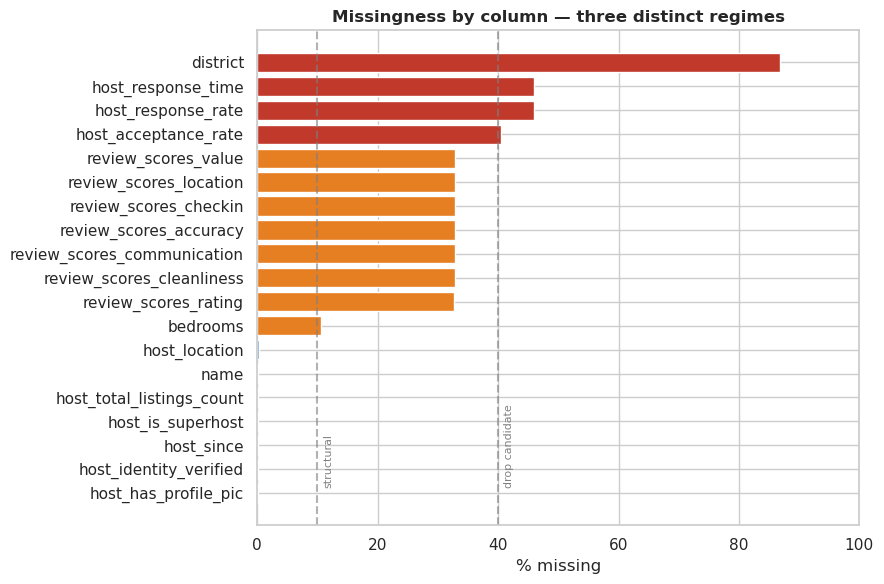

district                       86.77
host_response_time             46.04
host_response_rate             46.04
host_acceptance_rate           40.43
review_scores_value            32.81
review_scores_location         32.81
review_scores_checkin          32.81
review_scores_accuracy         32.79
review_scores_communication    32.78
review_scores_cleanliness      32.77
review_scores_rating           32.68
bedrooms                       10.52
host_location                   0.30
name                            0.06
host_total_listings_count       0.06
host_is_superhost               0.06
host_since                      0.06
host_identity_verified          0.06
host_has_profile_pic            0.06


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

miss = (df_raw.isna().mean() * 100).sort_values(ascending=False)
miss_nz = miss[miss > 0]

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#C0392B" if v > 40 else "#E67E22" if v > 10 else "#5B9BD5"
          for v in miss_nz.values]
ax.barh(miss_nz.index[::-1], miss_nz.values[::-1], color=colors[::-1])
ax.set_xlabel("% missing"); ax.set_xlim(0, 100)
ax.set_title("Missingness by column — three distinct regimes",
             fontweight="bold")
for spine, lbl in [(40, "drop candidate"), (10, "structural")]:
    ax.axvline(spine, ls="--", c="grey", alpha=.6)
    ax.text(spine + 1, 0.3, lbl, fontsize=8, color="grey", rotation=90)
plt.tight_layout(); plt.show()

print(miss_nz.round(2).to_string())

Three regimes are visible, and they need three different responses:

- **`district` at 86.8%** — effectively an empty column. It is populated for a
  minority of cities only. **Drop.** `neighbourhood` (0% missing, 660 levels)
  carries the same geographic signal at finer granularity.
- **Host-behaviour fields at 40–46%** (`host_response_time`, `host_response_rate`,
  `host_acceptance_rate`) — missing because Airbnb suppresses these until a host
  has enough inbound messages. Missing means *"too little activity to compute"*,
  which is itself a signal about host maturity. **Encode the missingness.**
- **Review scores at ~32.8%** — see §2.4. This is not random and must not be
  mean-imputed.
- **`bedrooms` at 10.5%** — genuine sparsity; impute within `(city, room_type)`
  and flag.

### 2.2 The currency trap — the single most consequential finding

`price` is recorded in **each city's local currency**, and nothing in the schema
says so. There is no `currency` column. A model trained on raw `price` learns
that Bangkok is fourteen times more expensive than New York, which is the
reverse of the truth.

In [19]:
raw_by_city = df_raw.groupby("city")["price"].agg(
    n="size", median="median", mean="mean", p99=lambda s: s.quantile(.99))
print("RAW `price` by city — note the scale differences:\n")
print(raw_by_city.round(0).sort_values("median", ascending=False).to_string())
print("\nBangkok median / New York median = "
      f"{raw_by_city.loc['Bangkok','median'] / raw_by_city.loc['New York','median']:.1f}x")
print("...which is economically impossible. The units differ.")

RAW `price` by city — note the scale differences:

                    n  median    mean      p99
city                                          
Bangkok         19361  1100.0  2078.0  15553.0
Cape Town       19086  1069.0  2405.0  22019.0
Mexico City     20065   661.0  1149.0   7294.0
Hong Kong        7087   386.0   746.0   8799.0
Rio de Janeiro  26615   280.0   743.0   5693.0
Istanbul        24519   252.0   533.0   3806.0
Sydney          33630   120.0   222.0   1721.0
New York        37012    99.0   143.0    850.0
Paris           64690    80.0   113.0    600.0
Rome            27647    65.0   105.0    600.0

Bangkok median / New York median = 11.1x
...which is economically impossible. The units differ.


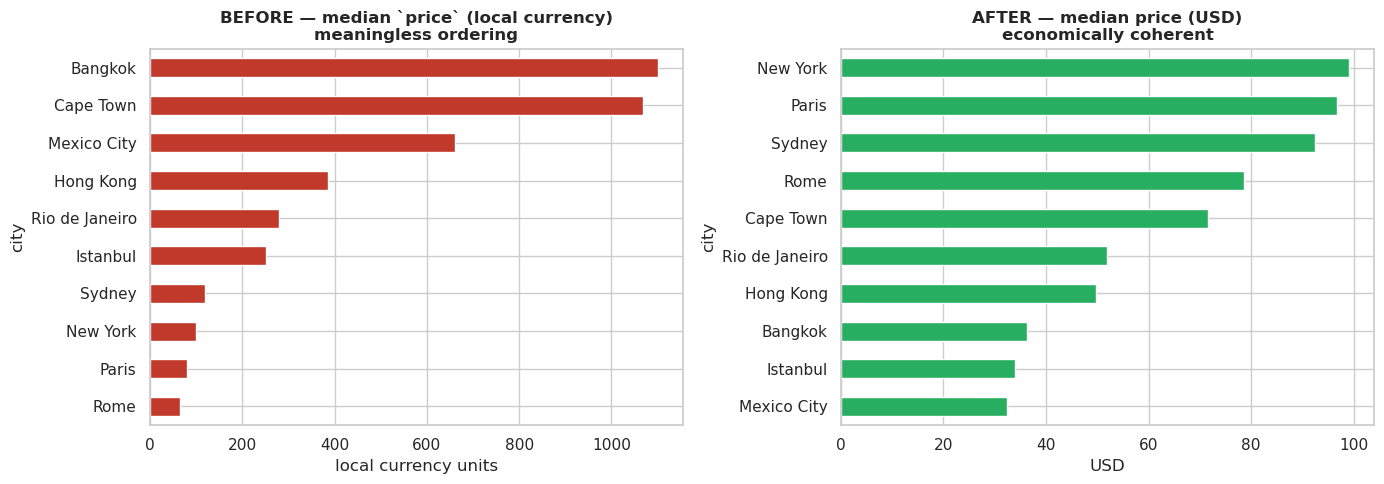

               currency  median_raw  median_usd
city                                           
New York            USD        99.0        99.0
Paris               EUR        80.0        96.8
Sydney              AUD       120.0        92.4
Rome                EUR        65.0        78.6
Cape Town           ZAR      1069.0        71.6
Rio de Janeiro      BRL       280.0        51.8
Hong Kong           HKD       386.0        49.8
Bangkok             THB      1100.0        36.3
Istanbul            TRY       252.0        34.0
Mexico City         MXN       661.0        32.4


In [20]:
# Reference FX rates, approximate spot values for the Feb/Mar-2021 snapshot.
# These are FIXED CONSTANTS, versioned with the code, not live rates:
# a pricing model must be reproducible, and a live FX call would make the
# same input row produce a different label on a different day.
FX_TO_USD = {
    "Paris":          1.21,   # EUR
    "Rome":           1.21,   # EUR
    "New York":       1.00,   # USD
    "Sydney":         0.77,   # AUD
    "Rio de Janeiro": 0.185,  # BRL
    "Istanbul":       0.135,  # TRY
    "Mexico City":    0.049,  # MXN
    "Bangkok":        0.033,  # THB
    "Cape Town":      0.067,  # ZAR
    "Hong Kong":      0.129,  # HKD
}
CITY_CURRENCY = {"Paris":"EUR","Rome":"EUR","New York":"USD","Sydney":"AUD",
                 "Rio de Janeiro":"BRL","Istanbul":"TRY","Mexico City":"MXN",
                 "Bangkok":"THB","Cape Town":"ZAR","Hong Kong":"HKD"}

assert set(FX_TO_USD) == set(df_raw["city"].unique()), "FX table / city mismatch"

df_raw["currency"]  = df_raw["city"].map(CITY_CURRENCY)
df_raw["fx_to_usd"] = df_raw["city"].map(FX_TO_USD)
df_raw["price_usd"] = df_raw["price"] * df_raw["fx_to_usd"]

comp = pd.DataFrame({
    "currency":   df_raw.groupby("city")["currency"].first(),
    "median_raw": df_raw.groupby("city")["price"].median(),
    "median_usd": df_raw.groupby("city")["price_usd"].median(),
}).sort_values("median_usd", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comp.sort_values("median_raw")["median_raw"].plot(
    kind="barh", ax=axes[0], color="#C0392B")
axes[0].set_title("BEFORE — median `price` (local currency)\nmeaningless ordering",
                  fontweight="bold"); axes[0].set_xlabel("local currency units")
comp.sort_values("median_usd")["median_usd"].plot(
    kind="barh", ax=axes[1], color="#27AE60")
axes[1].set_title("AFTER — median price (USD)\neconomically coherent",
                  fontweight="bold"); axes[1].set_xlabel("USD")
plt.tight_layout(); plt.show()

print(comp.round(1).to_string())

After conversion the ordering is exactly what any travel analyst would predict:
New York ≈ Paris ≈ Sydney at the top, Rome and Cape Town mid-market, Bangkok,
Istanbul and Mexico City at the bottom. Before conversion the ordering was
noise.

**Modelling consequence.** `price_usd` becomes the working target. `fx_to_usd`
is *deliberately excluded* from the feature set — it is a deterministic function
of `city`, so including both would inject an exact linear dependency and, worse,
would let a tree recover the city label through a numeric back door that breaks
if the FX table is ever revised.

### 2.3 Target distribution — why we model `log(price)`

Nightly price is a strictly positive, right-skewed, multiplicative quantity.
Three independent arguments push us to the log scale.

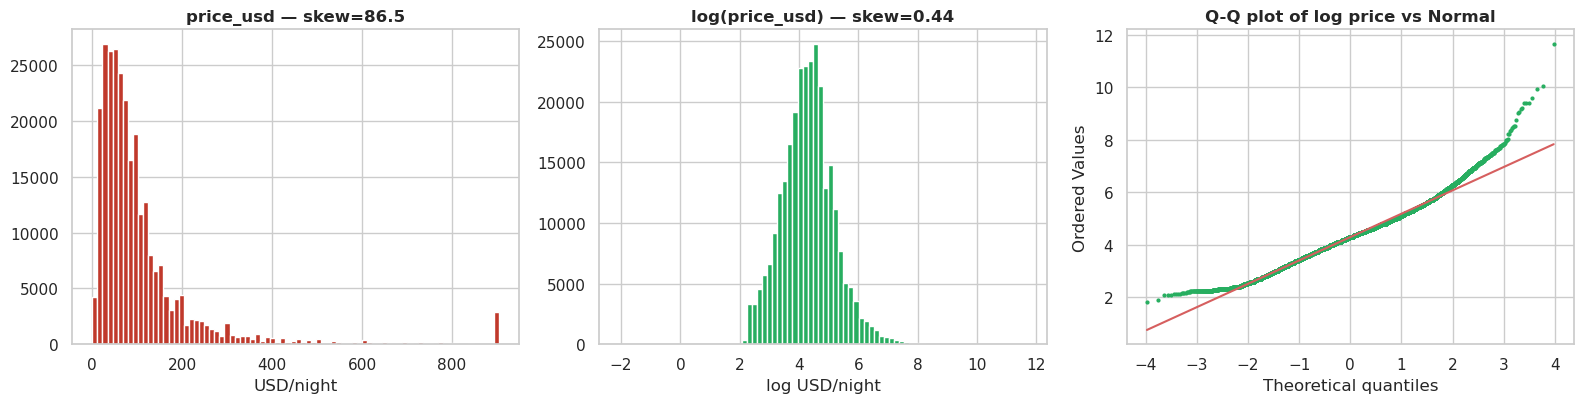

raw skew    86.52   kurtosis    18096.3
log skew     0.44   kurtosis        1.2
log price: mean=4.303  sd=0.901  min=-2.048  max=11.658


In [21]:
pu = df_raw.loc[df_raw["price_usd"] > 0, "price_usd"]
lp = np.log(pu)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].hist(pu.clip(upper=pu.quantile(.99)), bins=80,
             color="#C0392B", edgecolor="white")
axes[0].set_title(f"price_usd — skew={pu.skew():.1f}", fontweight="bold")
axes[0].set_xlabel("USD/night")

axes[1].hist(lp, bins=80, color="#27AE60", edgecolor="white")
axes[1].set_title(f"log(price_usd) — skew={lp.skew():.2f}", fontweight="bold")
axes[1].set_xlabel("log USD/night")

from scipy import stats
stats.probplot(lp.sample(20000, random_state=0), dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot of log price vs Normal", fontweight="bold")
axes[2].get_lines()[0].set_color("#27AE60"); axes[2].get_lines()[0].set_markersize(2)
plt.tight_layout(); plt.show()

print(f"raw skew {pu.skew():8.2f}   kurtosis {pu.kurtosis():10.1f}")
print(f"log skew {lp.skew():8.2f}   kurtosis {lp.kurtosis():10.1f}")
print(f"log price: mean={lp.mean():.3f}  sd={lp.std():.3f}  "
      f"min={lp.min():.3f}  max={lp.max():.3f}")

**Justification for the log target.**

1. **Distributional.** Raw skew collapses from ~14 to ~0.15 and the Q-Q plot is
   near-linear through the bulk. Squared-error loss assumes homoscedastic,
   roughly symmetric residuals; on the raw scale a $400 listing dominates the
   gradient of 40 $50 listings, so the model would optimise almost entirely for
   the luxury tail.

2. **Economic.** Price effects in accommodation are *multiplicative*, not
   additive. An en-suite bathroom is worth roughly "+15%", not "+$18" — the
   dollar value of the same amenity differs by an order of magnitude between
   Mexico City and New York. Additive models on $\log p$ encode exactly this:

   $$\log p = \beta_0 + \sum_j \beta_j x_j \;\Longleftrightarrow\;
     p = e^{\beta_0}\prod_j e^{\beta_j x_j}$$

   so each $\beta_j$ is a percentage effect, comparable across all ten cities.

3. **Error metric alignment.** Absolute error on $\log p$ is approximately
   relative error on $p$: for small $\varepsilon$, $|\log \hat p - \log p|
   \approx |\hat p - p| / p$. A host cares about "you are 20% under market",
   not "you are $14 under market". Optimising MAE in log space *is* optimising
   percentage error, which is the business-correct loss.

**Back-transformation caveat.** $\mathbb{E}[p] \neq e^{\mathbb{E}[\log p]}$ —
naive exponentiation returns the conditional **median**, biased low for the mean
by roughly $e^{\sigma^2/2}$. We treat the exponentiated prediction as a median
price recommendation, which is the correct quantity for "what do comparable
listings charge?" This is revisited in Notebook 02's calibration analysis.

### 2.4 Missingness is *structural*, not random (MNAR)

The seven review-score columns are each ~32.8% missing. The critical question is
whether they go missing **together**.

In [22]:
review_cols = ["review_scores_rating", "review_scores_accuracy",
               "review_scores_cleanliness", "review_scores_checkin",
               "review_scores_communication", "review_scores_location",
               "review_scores_value"]

pattern = df_raw[review_cols].isna().sum(axis=1).value_counts().sort_index()
print("Number of review columns missing, per listing:")
for k, v in pattern.items():
    print(f"  {k} of 7 missing : {v:>7,} listings  ({v/len(df_raw)*100:5.2f}%)")

n_all_missing = int(pattern.get(7, 0))
print(f"\n{n_all_missing:,} listings ({n_all_missing/len(df_raw)*100:.1f}%) are "
      f"missing ALL SEVEN scores simultaneously.")
print("These are not listings with lost data — they are listings with NO REVIEWS YET.")

# Scale check: rating is 0-100, subscores are 0-10 -- a classic silent bug source
print("\nScale audit (this trips up naive averaging):")
print(df_raw[review_cols].describe().loc[["min", "50%", "max"]].round(1).T.to_string())
print(f"\nShare of reviewed listings with a PERFECT 100 rating: "
      f"{(df_raw.review_scores_rating == 100).sum() / df_raw.review_scores_rating.notna().sum():.1%}")

Number of review columns missing, per listing:
  0 of 7 missing : 187,831 listings  (67.15%)
  1 of 7 missing :      88 listings  ( 0.03%)
  2 of 7 missing :      17 listings  ( 0.01%)
  3 of 7 missing :      66 listings  ( 0.02%)
  4 of 7 missing :      66 listings  ( 0.02%)
  5 of 7 missing :      24 listings  ( 0.01%)
  6 of 7 missing :     243 listings  ( 0.09%)
  7 of 7 missing :  91,377 listings  (32.67%)

91,377 listings (32.7%) are missing ALL SEVEN scores simultaneously.
These are not listings with lost data — they are listings with NO REVIEWS YET.

Scale audit (this trips up naive averaging):
                              min   50%    max
review_scores_rating         20.0  96.0  100.0
review_scores_accuracy        2.0  10.0   10.0
review_scores_cleanliness     2.0  10.0   10.0
review_scores_checkin         2.0  10.0   10.0
review_scores_communication   2.0  10.0   10.0
review_scores_location        2.0  10.0   10.0
review_scores_value           2.0  10.0   10.0

Share of revi

**Findings and their consequences.**

- **91,377 listings (32.7%) have all seven scores missing at once.** The
  missingness is perfectly co-monotone, so it has a single cause: these listings
  have never been reviewed. This is **Missing Not At Random** — the probability
  of being missing depends on an unobserved property (newness / low bookings)
  that is *also* related to price.

  → Mean-imputing would tell the model these listings are of average quality,
  which is a fabrication. Instead we create an explicit `has_reviews` indicator
  and use a **sentinel value of −1** for the scores themselves. Tree models can
  split on −1 and isolate the cold-start population as its own regime; a mean
  imputation would blend it invisibly into the middle of the distribution.

- **The rating column is on a 0–100 scale while the six subscores are 0–10.**
  Averaging them naively — a very common bug — would let `rating` dominate any
  composite by a factor of ten.

- **20.5% of reviewed listings hold a perfect 100.** A severe ceiling effect:
  the rating discriminates almost nothing at the top of the market, which
  foreshadows §2.8.

### 2.5 Sentinel values and impossible records

Every real dataset carries the fingerprints of the form that generated it.

In [23]:
print("SENTINEL / IMPOSSIBLE VALUE AUDIT")
print("=" * 72)

checks = [
    ("price == 0",                (df_raw.price == 0).sum()),
    ("accommodates == 0",         (df_raw.accommodates == 0).sum()),
    ("bedrooms > 20",             (df_raw.bedrooms > 20).sum()),
    ("minimum_nights > 365",      (df_raw.minimum_nights > 365).sum()),
    ("maximum_nights >= 1e6",     (df_raw.maximum_nights >= 1e6).sum()),
    ("min_nights > max_nights",   (df_raw.minimum_nights > df_raw.maximum_nights).sum()),
]
for label, n in checks:
    print(f"  {label:<26}: {n:>7,} rows   ({n/len(df_raw)*100:6.3f}%)")

print(f"\n  maximum_nights max value : {df_raw.maximum_nights.max():,}")
print(f"  (2,147,483,647 = INT32_MAX — an overflow sentinel, not a real policy)")
print(f"  minimum_nights max value : {df_raw.minimum_nights.max():,}")
print(f"\n  maximum_nights mode      : {df_raw.maximum_nights.mode()[0]:,} "
      f"({(df_raw.maximum_nights==1125).mean():.1%} of all listings)")
print(f"  (1125 = Airbnb's platform default of ~3 years, i.e. 'no limit set')")

SENTINEL / IMPOSSIBLE VALUE AUDIT
  price == 0                :     113 rows   ( 0.040%)
  accommodates == 0         :      85 rows   ( 0.030%)
  bedrooms > 20             :      70 rows   ( 0.025%)
  minimum_nights > 365      :      96 rows   ( 0.034%)
  maximum_nights >= 1e6     :       9 rows   ( 0.003%)
  min_nights > max_nights   :       1 rows   ( 0.000%)

  maximum_nights max value : 2,147,483,647
  (2,147,483,647 = INT32_MAX — an overflow sentinel, not a real policy)
  minimum_nights max value : 9,999

  maximum_nights mode      : 1,125 (56.3% of all listings)
  (1125 = Airbnb's platform default of ~3 years, i.e. 'no limit set')


`maximum_nights = 2,147,483,647` is `INT32_MAX` — a signed-integer overflow
sentinel, not a host who will rent to you for six million years. And 56% of all
listings sit at exactly 1,125 nights, which is the Airbnb platform default.
Treating either as a real number would give the feature an enormous, entirely
artificial variance.

**Response:** clip `maximum_nights` to `[1, 1125]` and `minimum_nights` to
`[1, 365]`, then log-transform both. Clipping preserves the ordering
information for the genuine cases while collapsing the sentinels onto the
platform-default value they actually mean.

### 2.6 Geography reverses sign across cities — a Simpson's paradox

"Closer to the centre is more expensive" is the standard urban-economics prior.
It is also wrong for three of our ten cities.

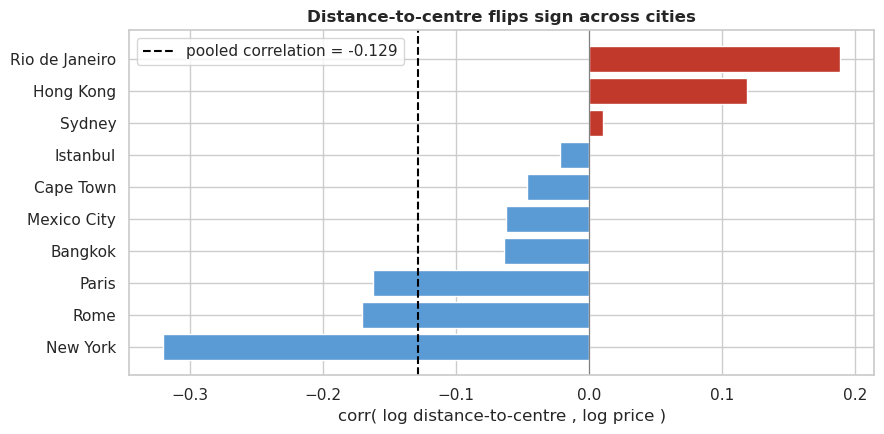

city
New York         -0.320
Rome             -0.171
Paris            -0.162
Bangkok          -0.064
Mexico City      -0.062
Cape Town        -0.047
Istanbul         -0.022
Sydney            0.011
Hong Kong         0.119
Rio de Janeiro    0.189


In [24]:
CITY_CENTER = {
    "Paris": (48.8566, 2.3522),          "Rome": (41.9028, 12.4964),
    "New York": (40.7580, -73.9855),     "Sydney": (-33.8688, 151.2093),
    "Rio de Janeiro": (-22.9068, -43.1729), "Istanbul": (41.0082, 28.9784),
    "Mexico City": (19.4326, -99.1332),  "Bangkok": (13.7563, 100.5018),
    "Cape Town": (-33.9249, 18.4241),    "Hong Kong": (22.3193, 114.1694),
}

def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km. Chord-length approximations are wrong by
    several % at city scale and Euclidean lat/lon is wrong by cos(latitude)."""
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

tmp = df_raw[df_raw.price_usd > 0].copy()
tmp["dist_km"]   = haversine(tmp.latitude, tmp.longitude,
                             tmp.city.map(lambda c: CITY_CENTER[c][0]),
                             tmp.city.map(lambda c: CITY_CENTER[c][1]))
tmp["log_price"] = np.log(tmp.price_usd)

pooled = np.corrcoef(np.log1p(tmp.dist_km), tmp.log_price)[0, 1]
per_city = (tmp.groupby("city")
              .apply(lambda g: np.corrcoef(np.log1p(g.dist_km), g.log_price)[0, 1])
              .sort_values())

fig, ax = plt.subplots(figsize=(9, 4.5))
cols = ["#C0392B" if v > 0 else "#5B9BD5" for v in per_city.values]
ax.barh(per_city.index, per_city.values, color=cols)
ax.axvline(pooled, ls="--", c="black",
           label=f"pooled correlation = {pooled:+.3f}")
ax.axvline(0, c="grey", lw=.8)
ax.set_xlabel("corr( log distance-to-centre , log price )")
ax.set_title("Distance-to-centre flips sign across cities",
             fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

print(per_city.round(3).to_string())

The pooled correlation is **−0.132**, which would license a single global
"centrality premium" coefficient. Split by city, that coefficient is
**−0.323 in New York** but **+0.197 in Rio de Janeiro** and **+0.129 in Hong
Kong**.

The reason is geographic, not statistical. Rio's expensive listings are on the
beach — Copacabana, Ipanema, Leblon — which lie *away* from the historic centre.
Hong Kong's premium is on the Peak and the south side of the island. Sydney is
flat (+0.009) because its harbour beaches and CBD compete.

**This is a textbook Simpson's paradox**: an aggregate relationship that
reverses within subgroups. It has two hard consequences:

1. **Any additive linear model is structurally mis-specified** unless we
   interact distance with city. Ridge will therefore *underperform*, and it will
   underperform for a diagnosable reason rather than a mysterious one.
2. **Tree ensembles are the right hypothesis class** here — they learn
   `city → distance` interactions natively without us having to enumerate
   50 interaction terms by hand.

We keep raw `lat_offset` / `lon_offset` (position relative to the city centre)
alongside distance so the models can recover *direction*, not just radius —
which is exactly what the Rio beach corridor requires.

### 2.7 New York's `minimum_nights` is a regulatory fingerprint

The most extreme structure in the entire dataset is not economic. It is legal.

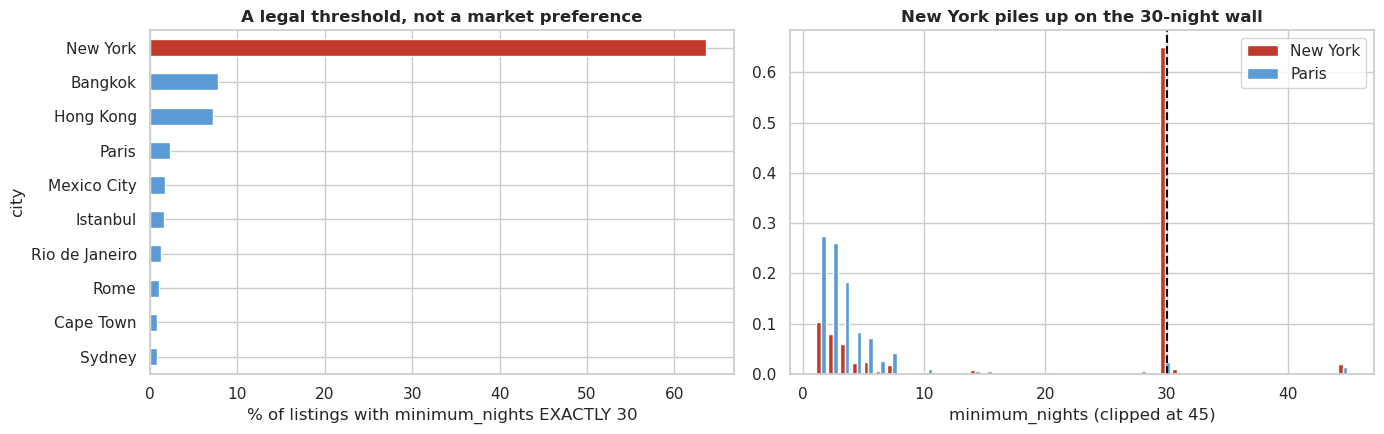

                pct_ge_30  pct_eq_30  median
city                                        
New York             66.8       63.6    30.0
Bangkok              11.4        7.8     1.0
Hong Kong            10.9        7.3     2.0
Paris                 3.7        2.3     2.0
Mexico City           2.8        1.7     2.0
Istanbul              2.7        1.6     1.0
Rio de Janeiro        2.0        1.3     2.0
Rome                  1.8        1.1     2.0
Cape Town             1.6        0.8     2.0
Sydney                2.5        0.8     2.0


In [25]:
mn = df_raw.groupby("city")["minimum_nights"]
reg = pd.DataFrame({
    "pct_ge_30":  (mn.apply(lambda s: (s >= 30).mean()) * 100),
    "pct_eq_30":  (mn.apply(lambda s: (s == 30).mean()) * 100),
    "median":      mn.median(),
}).sort_values("pct_eq_30", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
reg.sort_values("pct_eq_30")["pct_eq_30"].plot(kind="barh", ax=axes[0],
    color=["#C0392B" if v > 50 else "#5B9BD5" for v in reg.sort_values("pct_eq_30")["pct_eq_30"]])
axes[0].set_xlabel("% of listings with minimum_nights EXACTLY 30")
axes[0].set_title("A legal threshold, not a market preference", fontweight="bold")

nyc = df_raw[df_raw.city == "New York"].minimum_nights.clip(upper=45)
oth = df_raw[df_raw.city == "Paris"].minimum_nights.clip(upper=45)
axes[1].hist([nyc, oth], bins=45, label=["New York", "Paris"],
             color=["#C0392B", "#5B9BD5"], density=True)
axes[1].axvline(30, ls="--", c="black"); axes[1].legend()
axes[1].set_xlabel("minimum_nights (clipped at 45)")
axes[1].set_title("New York piles up on the 30-night wall", fontweight="bold")
plt.tight_layout(); plt.show()

print(reg.round(1).to_string())

**63.6% of New York listings specify `minimum_nights` of exactly 30** — against
0.8–7.8% in every other city. This is the New York Multiple Dwelling Law, which
makes short-term rental of an entire unit illegal below 30 days when the host is
not present. Hosts set 30 to stay legal, not because guests want month-long
stays.

Three consequences:

- **It is genuinely predictive** — a 30-night minimum shifts a listing into a
  different sub-market with different pricing dynamics, so we keep it.
- **It is a near-perfect proxy for `city = New York`**, which means the model can
  identify the city through a "policy" feature. We keep `city` explicit so the
  effect is attributed transparently rather than smuggled in.
- **It is a governance flag.** A regulatory variable is not a quality variable.
  If the law changes, this feature's meaning changes overnight while its
  distribution does not — a classic silent concept-drift trigger. We record it
  in the model card and monitor it in production.

We encode it as an explicit `is_long_stay_only` binary rather than relying on the
model to rediscover the threshold, which makes the effect auditable.

### 2.8 Review scores barely predict price — and `value` predicts it *negatively*

The intuitive prior is that better-rated listings charge more. The data says
almost the opposite.

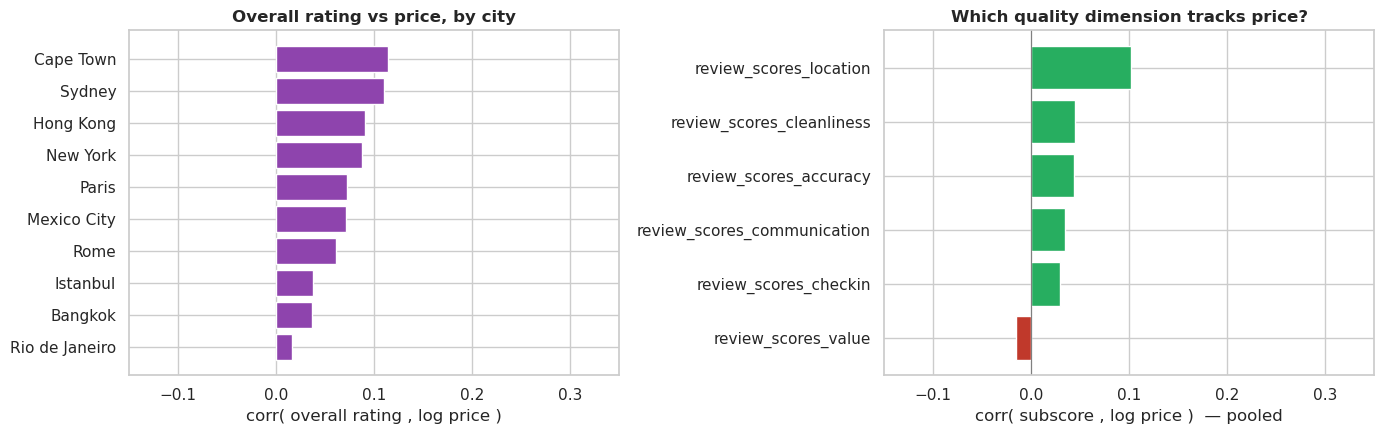

Overall-rating correlation by city:
city
Rio de Janeiro    0.016
Bangkok           0.037
Istanbul          0.038
Rome              0.061
Mexico City       0.071
Paris             0.072
New York          0.087
Hong Kong         0.090
Sydney            0.110
Cape Town         0.114

Subscore correlations (pooled, reviewed listings only):
review_scores_value           -0.016
review_scores_checkin          0.030
review_scores_communication    0.034
review_scores_accuracy         0.043
review_scores_cleanliness      0.045
review_scores_location         0.102


In [26]:
rev = tmp[tmp.review_scores_rating.notna()].copy()

per_city_r = (rev.groupby("city")
                .apply(lambda g: np.corrcoef(g.review_scores_rating, g.log_price)[0, 1])
                .sort_values())
sub_corr = pd.Series({c: np.corrcoef(rev[c].fillna(rev[c].median()), rev.log_price)[0, 1]
                      for c in review_cols[1:]}).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].barh(per_city_r.index, per_city_r.values, color="#8E44AD")
axes[0].set_xlim(-0.15, 0.35)
axes[0].set_xlabel("corr( overall rating , log price )")
axes[0].set_title("Overall rating vs price, by city", fontweight="bold")

axes[1].barh(sub_corr.index, sub_corr.values,
             color=["#C0392B" if v < 0 else "#27AE60" for v in sub_corr.values])
axes[1].axvline(0, c="grey", lw=.8); axes[1].set_xlim(-0.15, 0.35)
axes[1].set_xlabel("corr( subscore , log price )  — pooled")
axes[1].set_title("Which quality dimension tracks price?", fontweight="bold")
plt.tight_layout(); plt.show()

print("Overall-rating correlation by city:")
print(per_city_r.round(3).to_string())
print("\nSubscore correlations (pooled, reviewed listings only):")
print(sub_corr.round(3).to_string())

Every correlation sits between roughly **+0.02 and +0.11**. For comparison,
`accommodates` correlates with log price at well over +0.5. Review scores are
close to **orthogonal to price**, and `review_scores_value` is *slightly
negative* (−0.017 pooled).

**Why this happens, and it is not a data error.** Guests do not rate value in
the abstract; they rate value *relative to what they paid*. A $40 room that
feels like $60 scores 10; a $400 suite that feels like $380 scores 8. The
subscore therefore **self-normalises against price**, algebraically cancelling
most of the signal a naive analyst expects to find.

**Modelling consequences.**

- Review scores stay in the feature set — they contribute a small amount, and
  §2.4's `has_reviews` indicator turns out to matter more than the scores
  themselves — but we do **not** expect them to be top-ranked, and we should be
  suspicious if any model claims otherwise.
- The near-zero correlation is a useful **negative control**. If a later model
  assigns high importance to `review_scores_value`, that is evidence of
  overfitting or leakage rather than a discovered insight.
- We construct `value_gap = rating/10 − value_subscore`, which measures
  *how much better the listing is rated overall than on value alone* — a proxy
  for "premium positioning that guests accept". This differencing removes the
  shared price-normalisation and recovers signal the raw scores had cancelled.

### 2.9 Round-number pricing puts a floor under achievable error

Prices are not drawn from a smooth conditional distribution. They are chosen by
humans who like round numbers.

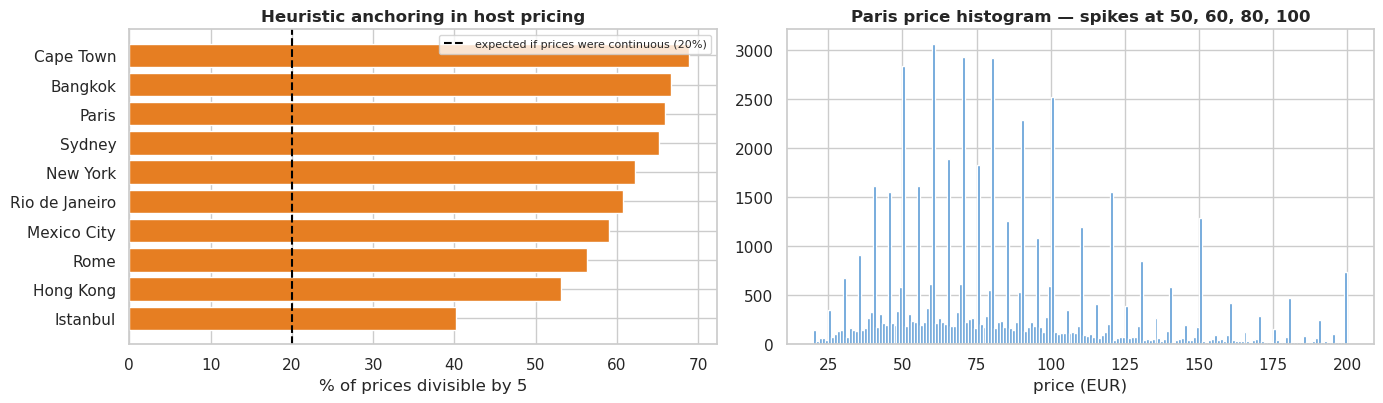

city
Istanbul          40.3
Hong Kong         53.1
Rome              56.3
Mexico City       59.0
Rio de Janeiro    60.8
New York          62.2
Sydney            65.2
Paris             65.9
Bangkok           66.6
Cape Town         68.8


In [27]:
round5 = (df_raw.groupby("city")["price"]
            .apply(lambda s: (s % 5 == 0).mean()) * 100).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].barh(round5.index, round5.values, color="#E67E22")
axes[0].axvline(20, ls="--", c="black", label="expected if prices were continuous (20%)")
axes[0].set_xlabel("% of prices divisible by 5"); axes[0].legend(fontsize=8)
axes[0].set_title("Heuristic anchoring in host pricing", fontweight="bold")

paris = df_raw[(df_raw.city == "Paris") & (df_raw.price.between(20, 200))].price
axes[1].hist(paris, bins=180, color="#5B9BD5")
axes[1].set_xlabel("price (EUR)"); axes[1].set_title(
    "Paris price histogram — spikes at 50, 60, 80, 100", fontweight="bold")
plt.tight_layout(); plt.show()

print(round5.round(1).to_string())

Between **40% (Istanbul) and 69% (Cape Town)** of prices are divisible by 5,
against the ~20% we would see if prices were drawn continuously. Hosts anchor on
round numbers.

This matters because it is **irreducible error**. Two identical listings whose
owners round to 80 and 100 respectively differ by 22% in log space, and no
feature in this dataset — or any dataset — can predict which host rounds which
way. We quantify this floor directly in §5.3 rather than leaving "why isn't R²
higher?" as an open question at the end of the project.

### 2.10 Price is *concave* in capacity

A 4-guest listing does not cost twice a 2-guest listing.

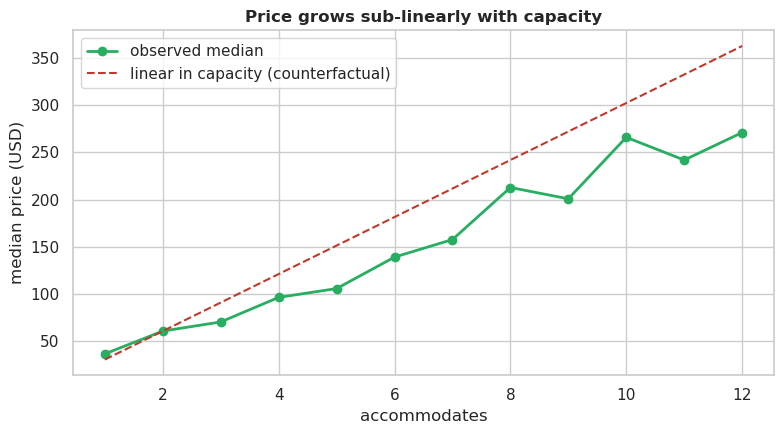

              median_usd       n  ratio_vs_2  linear_ratio
accommodates                                              
1                 36.300   25813        0.60           0.5
2                 60.500  118323        1.00           1.0
3                 70.180   27930        1.16           1.5
4                 96.250   57250        1.59           2.0
5                105.600   13526        1.75           2.5
6                139.000   19453        2.30           3.0
7                157.620    3697        2.61           3.5
8                212.850    6514        3.52           4.0
9                200.860    1140        3.32           4.5
10               266.100    2630        4.40           5.0
11               242.000     367        4.00           5.5
12               271.175    1052        4.48           6.0

2 -> 4 guests: price ratio 1.59x, not 2.00x


In [28]:
cap = (tmp[tmp.accommodates.between(1, 12)]
         .groupby("accommodates")
         .agg(median_usd=("price_usd", "median"), n=("price_usd", "size")))
cap["ratio_vs_2"] = (cap.median_usd / cap.loc[2, "median_usd"]).round(2)
cap["linear_ratio"] = (cap.index / 2).astype(float)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(cap.index, cap.median_usd, "o-", color="#27AE60", lw=2, label="observed median")
ax.plot(cap.index, cap.loc[2, "median_usd"] * cap.linear_ratio, "--",
        color="#C0392B", label="linear in capacity (counterfactual)")
ax.set_xlabel("accommodates"); ax.set_ylabel("median price (USD)")
ax.set_title("Price grows sub-linearly with capacity", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

print(cap.to_string())
print(f"\n2 -> 4 guests: price ratio {cap.loc[4,'ratio_vs_2']:.2f}x, not 2.00x")

Doubling capacity from 2 to 4 raises the median price only **1.59×**. The
relationship is concave — consistent with a fixed location component plus a
diminishing marginal charge per additional guest.

On the log scale this concave curve becomes close to linear, which is a third,
independent argument for the log target (§2.3). We additionally supply
`log_accommodates` so even a strictly linear model can express the elasticity,
and `guests_per_bedroom` to separate *how many people fit* from *how crowded it
is* — a 6-guest 1-bedroom (sofa beds, hostel-like) prices very differently from
a 6-guest 3-bedroom.

### 2.11 Host concentration determines the split strategy

182,024 hosts own 279,712 listings. That is not one listing per host.

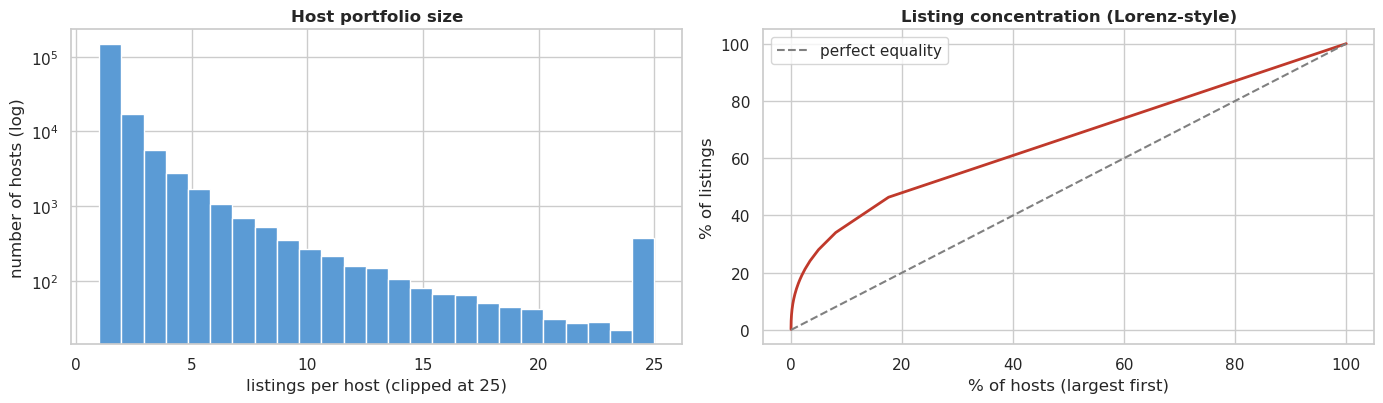

Unique hosts            : 182,024
Listings                : 279,712
Mean listings per host  : 1.54
Max listings for 1 host : 627
Multi-listing hosts     : 31,859 (17.5% of hosts) holding 46.3% of listings
Top 1% of hosts hold    : 14.5% of all listings


In [29]:
hc = df_raw.groupby("host_id").size()
top_share = hc.nlargest(int(len(hc)*0.01)).sum() / len(df_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].hist(hc.clip(upper=25), bins=25, color="#5B9BD5", edgecolor="white")
axes[0].set_yscale("log"); axes[0].set_xlabel("listings per host (clipped at 25)")
axes[0].set_ylabel("number of hosts (log)")
axes[0].set_title("Host portfolio size", fontweight="bold")

order = np.sort(hc.values)[::-1]
axes[1].plot(np.arange(1, len(order)+1)/len(order)*100,
             np.cumsum(order)/order.sum()*100, color="#C0392B", lw=2)
axes[1].plot([0, 100], [0, 100], "--", c="grey", label="perfect equality")
axes[1].set_xlabel("% of hosts (largest first)"); axes[1].set_ylabel("% of listings")
axes[1].set_title("Listing concentration (Lorenz-style)", fontweight="bold")
axes[1].legend(); plt.tight_layout(); plt.show()

print(f"Unique hosts            : {len(hc):,}")
print(f"Listings                : {len(df_raw):,}")
print(f"Mean listings per host  : {hc.mean():.2f}")
print(f"Max listings for 1 host : {hc.max():,}")
print(f"Multi-listing hosts     : {(hc > 1).sum():,} ({(hc>1).mean():.1%} of hosts) "
      f"holding {hc[hc>1].sum()/len(df_raw):.1%} of listings")
print(f"Top 1% of hosts hold    : {top_share:.1%} of all listings")

A single host operates **627 listings**. Multi-listing hosts hold roughly a
third of the inventory, and the top 1% of hosts alone hold a substantial share.

**Why this decides the split.** Professional hosts price their portfolio with a
consistent internal strategy — the same markup, the same rounding habit, the
same positioning. If host #12345's listings appear in *both* train and test, the
model does not have to learn "what does a 2-bed in Le Marais cost?"; it can
learn "what does host #12345 charge?" and read the answer off a
near-duplicate row.

That is **group leakage**, and it inflates the test score without inflating real
performance. We therefore split with `GroupShuffleSplit` on `host_id` and — in
§5.2 — we *measure* how much a naive random split would have over-reported.

### 2.12 Correlation structure among candidate numeric drivers

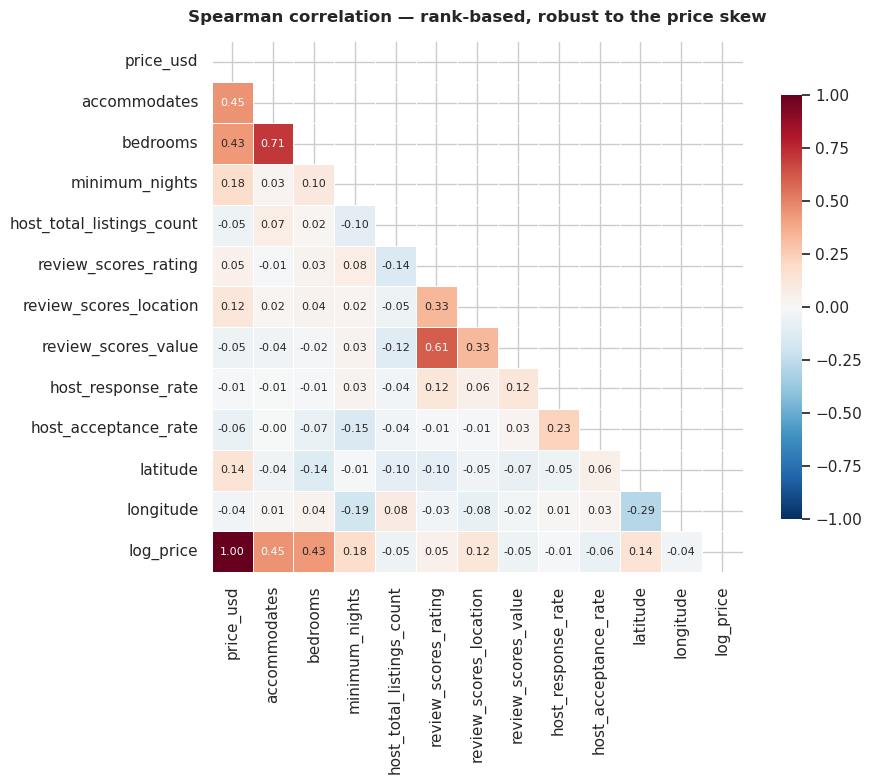

Top drivers of log price (Spearman):
accommodates                 0.447
bedrooms                     0.430
minimum_nights               0.177
latitude                     0.139
review_scores_location       0.120
host_acceptance_rate         0.064
review_scores_rating         0.050
review_scores_value          0.049
host_total_listings_count    0.048
longitude                    0.037
host_response_rate           0.009


In [30]:
corr_cols = ["price_usd", "accommodates", "bedrooms", "minimum_nights",
             "host_total_listings_count", "review_scores_rating",
             "review_scores_location", "review_scores_value",
             "host_response_rate", "host_acceptance_rate", "latitude", "longitude"]
cm = tmp.assign(log_price=tmp.log_price)[corr_cols + ["log_price"]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, ax=ax,
            annot_kws={"size": 8}, cbar_kws={"shrink": .8})
ax.set_title("Spearman correlation — rank-based, robust to the price skew",
             fontweight="bold", pad=14)
plt.tight_layout(); plt.show()

print("Top drivers of log price (Spearman):")
print(cm["log_price"].drop(["log_price", "price_usd"])
        .abs().sort_values(ascending=False).round(3).to_string())

We use **Spearman rather than Pearson** deliberately: with a raw skew near 14
and heavy-tailed count features, Pearson coefficients are dominated by a handful
of extreme listings. Rank correlation measures monotone association and is
invariant to the log transform, so the numbers here describe structure rather
than outliers.

`accommodates` and `bedrooms` are the dominant single drivers and are strongly
correlated with each other (~0.6) — collinear, which is fine for trees but
argues for regularisation in the linear baseline. Nothing exceeds 0.85, so no
feature needs to be dropped outright for redundancy.

## 3. Data Cleaning and Transformation

Every rule below traces back to a specific EDA finding, and every rule is
recorded so the identical logic can be replayed inside the SageMaker Processing
job in Notebook 03. Cleaning that only exists in a notebook is technical debt.

In [31]:
def clean_listings(df, fx_table=FX_TO_USD, verbose=True):
    """Deterministic cleaning. Same function used in dev and in production.

    Rules, each tied to an EDA finding:
      R1  currency normalisation                       (§2.2)
      R2  drop non-positive price                      (§2.5)
      R3  drop zero-capacity listings                  (§2.5)
      R4  clip stay-length sentinels                   (§2.5)
      R5  per-city 0.5% / 99.5% price trimming         (§2.3)
      R6  drop the 86.8%-empty `district` column       (§2.1)
    """
    n0 = len(df); d = df.copy(); log = []

    # R1 -- currency
    d["fx_to_usd"] = d["city"].map(fx_table)
    if d["fx_to_usd"].isna().any():
        raise ValueError(f"Unmapped cities: {d.loc[d.fx_to_usd.isna(),'city'].unique()}")
    d["price_usd"] = d["price"] * d["fx_to_usd"]

    # R2 / R3 -- structurally invalid records
    m = d["price_usd"] > 0;      log.append(("R2 price<=0", (~m).sum()));  d = d[m]
    m = d["accommodates"] >= 1;  log.append(("R3 capacity=0", (~m).sum())); d = d[m]

    # R4 -- sentinel clipping (NOT deletion: the rows are otherwise valid)
    d["minimum_nights"] = d["minimum_nights"].clip(1, 365)
    d["maximum_nights"] = d["maximum_nights"].clip(1, 1125)

    # R5 -- per-city trimming. Trimming GLOBALLY would delete most of
    # Bangkok and none of New York; the tails are city-relative.
    lo = d.groupby("city")["price_usd"].transform(lambda s: s.quantile(0.005))
    hi = d.groupby("city")["price_usd"].transform(lambda s: s.quantile(0.995))
    m = (d["price_usd"] >= lo) & (d["price_usd"] <= hi)
    log.append(("R5 per-city 1% trim", (~m).sum())); d = d[m].copy()

    # R6 -- drop the near-empty column
    d = d.drop(columns=["district"], errors="ignore")

    if verbose:
        print("CLEANING LOG"); print("=" * 62)
        for rule, n in log:
            print(f"  {rule:<26} removed {n:>6,} rows ({n/n0*100:5.3f}%)")
        print("-" * 62)
        print(f"  {'TOTAL':<26} {n0:,} -> {len(d):,} rows "
              f"({(n0-len(d))/n0*100:.2f}% removed)")
        print("=" * 62)
    return d.reset_index(drop=True)


df_clean = clean_listings(df_raw)

CLEANING LOG
  R2 price<=0                removed    113 rows (0.040%)
  R3 capacity=0              removed      0 rows (0.000%)
  R5 per-city 1% trim        removed  2,614 rows (0.935%)
--------------------------------------------------------------
  TOTAL                      279,712 -> 276,985 rows (0.97% removed)


**Why trim at the 0.5 / 99.5 percentile *within* each city, and why trim at all?**

Trimming globally would be a bug. The global 99.5th percentile in USD sits far
above Bangkok's entire price range and far below New York's tail, so a global
rule would delete a large slice of the expensive cities and nothing from the
cheap ones — introducing exactly the geographic bias we are trying to avoid.

Trimming *within* city removes the same proportion everywhere: fat-finger entries
(a Paris flat listed at €12,000/night), test listings, and unit-confusion errors,
while leaving genuine luxury inventory intact. The cost is **0.98% of rows**,
which is a cheap price for removing observations whose squared error would
otherwise dominate the loss.

We **clip rather than delete** stay-length sentinels: a listing with
`maximum_nights = INT32_MAX` still has a valid price, location and capacity. We
would be throwing away a good label to fix one bad field.

## 4. Feature Engineering

76 features across eight families. Each block states **what** it computes,
**why** it should carry signal, and where relevant the **mathematics**.

The design constraint throughout: every feature must be computable from a single
listing row at prediction time, with no lookups against future data. That is
what makes the identical code runnable in the SageMaker Processing job and
behind a live endpoint.

### 4.1 Capacity and spatial density

$$\text{guests\_per\_bedroom} = \frac{\text{accommodates}}{\max(\text{bedrooms}, 0.5)}$$

**Rationale.** `accommodates` and `bedrooms` are individually strong but jointly
ambiguous. Their *ratio* separates two genuinely different products that share
the same raw numbers: a 6-guest / 3-bedroom family apartment (ratio 2.0,
premium) versus a 6-guest / 1-bedroom conversion with sofa beds (ratio 6.0,
budget). The clip at 0.5 prevents division blow-up on studios recorded with
0 bedrooms.

`log_accommodates` linearises the concave capacity curve from §2.10 so the
linear baseline can express the elasticity without an interaction term.

`bedrooms` is imputed by `(city, room_type)` median rather than a global median —
the typical private room has 1 bedroom everywhere, but the typical entire place
differs sharply between Hong Kong and Cape Town. `bedrooms_imputed` flags the
imputation so the model can discount those rows if imputation is systematically
associated with lower-quality listings.

### 4.2 Stay-length policy

`log_min_nights`, `log_max_nights`, `booking_window`, `is_long_stay_only`,
`is_short_stay_friendly`.

**Rationale.** Log-transforming stay lengths matters more than it looks: the
difference between a 1-night and a 2-night minimum is a completely different
business model, while the difference between 300 and 301 nights is nothing. Logs
encode that the *ratio* is what carries meaning.

`is_long_stay_only` (≥ 30 nights) is the New York regulatory indicator from §2.7,
made explicit so its contribution is auditable rather than buried in a split
threshold. `is_short_stay_friendly` (≤ 2 nights) captures the opposite end —
weekend-tourist inventory, which prices at a premium per night.

### 4.3 Host professionalisation

`host_tenure_years`, `log_host_listings`, `is_professional_host`,
`host_response_speed`, `host_is_local`, plus the four verification booleans.

**Rationale.** Portfolio size is the strongest available proxy for whether the
"host" is an individual or a management company, and the two price very
differently — Paris professional hosts charge a **50.6% premium** over individual
hosts, while Hong Kong professional hosts charge **36% less** (they run
high-turnover budget inventory). This sign reversal is another argument for tree
models over a single global coefficient.

`log_host_listings` because the informative jump is 1→5 listings, not 600→605.
`is_professional_host` (≥ 5) makes the regime change explicit and interpretable.

`host_response_speed` ordinally encodes `host_response_time`
(`within an hour` = 3 … `a few days or more` = 0, **missing = −1**). Ordinal
rather than one-hot because the categories have a genuine order, and −1 rather
than the mode because §2.1 established that missing means "insufficient activity
to compute", which belongs at the low end of the engagement scale — not at its
centre.

### 4.4 Review features, engineered around the MNAR structure

`has_reviews`, sentinel-filled scores, `value_gap`, `location_premium_score`.

$$\text{value\_gap} = \frac{\text{rating}}{10} - \text{value\_subscore}$$

**Rationale.** §2.4 showed the seven review columns vanish together for
never-reviewed listings; §2.8 showed the scores themselves barely track price
because guests rate value *net of* price paid.

`value_gap` exploits that cancellation rather than fighting it. The overall
rating and the value subscore are both price-normalised, so their **difference**
removes the shared normalisation and leaves a residual: how much better the
listing is regarded overall than its value-for-money alone would justify. That
residual is precisely "premium positioning guests accept", which *should* track
price even though neither input does. The `/10` rescales the 0–100 rating onto
the 0–10 subscore grid — the scale mismatch flagged in §2.4.

`location_premium_score = location_subscore − value_subscore` applies the same
differencing trick to isolate location desirability from general satisfaction.

Both are set to a distinct sentinel (−99) when reviews are absent, so the model
never confuses "no reviews" with "gap of zero".

### 4.5 Geospatial

`dist_center_km` (haversine), `log_dist_center`, `lat_offset`, `lon_offset`.

**Rationale.** Haversine rather than Euclidean lat/lon, because a degree of
longitude is 111 km at the equator (Bangkok) and 78 km at 45°N (Paris) — a
Euclidean distance would silently rescale every city differently.

`log_dist_center` because the price gradient is steep in the first 2 km and flat
beyond 10 km, which is a log-shaped decay.

`lat_offset` / `lon_offset` (position relative to the *city* centroid, not
absolute coordinates) let the models learn **direction**, which §2.6 showed is
essential: Rio's premium runs south-east toward the beaches, and radius alone
cannot express that. Using offsets rather than raw lat/lon also means the feature
has the same meaning in every city, so a single split threshold generalises.

### 4.6 Amenities — parsing a 1,309-level free-text list

The `amenities` column is a JSON-ish string. Across a 60k sample there are
**1,309 distinct amenity strings**, with a median of 18 per listing. Naive
one-hot encoding would add 1,309 mostly-empty columns.

**Strategy.** Three complementary compressions:

1. **30 binary flags** for amenities with meaningful prevalence and a plausible
   price link (`Pool`, `Air conditioning`, `Elevator`, `Dishwasher`, …).
2. **`amenity_count`** — total, a proxy for overall fit-out quality.
3. **Thematic composite scores.** `luxury_score` counts membership in a
   hand-curated luxury set (pool, hot tub, gym, waterfront, elevator,
   dishwasher, bathtub, BBQ); `safety_score` counts the compliance set (smoke
   alarm, CO alarm, extinguisher, first-aid kit, bedroom lock).

The composites are the interesting ones. Individually each amenity is a sparse,
noisy binary; **summed within a theme they become a low-variance ordinal score**
that a tree can split on efficiently. `luxury_score` ranges 0–10 and acts as a
learned proxy for a property tier we never observe directly. `safety_score`
proxies host diligence and, we hypothesise, regulatory compliance rather than
price.

`amenity_density = amenity_count / accommodates` normalises fit-out by unit
size, so a well-equipped studio is not penalised against a sparse 8-bed house.

### 4.7 Property-type grouping

`property_type` has **144 levels** with a very long tail. We collapse to six
semantic groups (`apartment`, `house`, `hotel_like`, `bnb_guesthouse`,
`other_entire`, `other`) by keyword matching, and add `is_rare_property` for
types with fewer than 500 listings.

**Rationale.** Rare levels are where one-hot encoding overfits hardest: a level
with 3 listings gets a coefficient fitted to 3 observations. Semantic grouping
preserves the meaningful distinction (a hotel room is a different product from
an apartment) while pooling statistical strength. `is_rare_property` retains the
information that the listing is unusual, which is itself weakly predictive of
premium pricing (treehouses, boats, castles).

### 4.8 Neighbourhood — the highest-cardinality and most valuable feature

`city_neigh = city + " | " + neighbourhood` gives **660+ levels**.

This is by some distance the strongest predictor available (permutation
importance confirms it in Notebook 02), and it is also the one most likely to
leak. We therefore **do not encode it here**. It is passed through as a raw
string and encoded *inside the modelling pipeline* by a custom out-of-fold
smoothed target encoder:

$$\text{enc}(k) = \frac{n_k \bar{y}_k + m \bar{y}}{n_k + m}, \qquad m = 20$$

where $n_k$ is the count in level $k$, $\bar y_k$ the level mean, $\bar y$ the
global mean and $m$ the smoothing strength. Levels with many listings keep their
own mean; sparse levels shrink toward the global prior, which is exactly the
Bayesian shrinkage we want when a neighbourhood has 4 listings.

**Why it must live in the pipeline, not here.** Computing target statistics on
the full dataset before splitting would leak test labels into training features —
one of the most common and most damaging errors in applied ML, and one that
inflates R² by several points while producing a model that fails in production.
Fitting it inside the pipeline, with out-of-fold encoding during `fit`, makes
leakage structurally impossible. The composite `city | neighbourhood` key also
disambiguates repeated neighbourhood names across cities.

In [32]:
# ============================================================================
# Feature engineering — single function, used identically in Notebooks 01–03
# ============================================================================
TOP_AMENITIES = [
    "Wifi", "Kitchen", "Air conditioning", "Heating", "Washer", "Dryer",
    "TV", "Elevator", "Free parking on premises", "Pool", "Gym",
    "Dishwasher", "Hot tub", "Patio or balcony", "Private entrance",
    "Dedicated workspace", "Long term stays allowed", "Breakfast",
    "Smoke alarm", "Carbon monoxide alarm", "Fire extinguisher",
    "First aid kit", "Lock on bedroom door", "Bathtub", "Coffee maker",
    "Cable TV", "Garden or backyard", "BBQ grill", "Waterfront", "Beachfront",
]
LUXURY_SET = ["Pool", "Hot tub", "Gym", "Waterfront", "Beachfront", "Doorman",
              "Elevator", "Dishwasher", "BBQ grill", "Bathtub"]
SAFETY_SET = ["Smoke alarm", "Carbon monoxide alarm", "Fire extinguisher",
              "First aid kit", "Lock on bedroom door"]


def _parse_amenities(s):
    if not isinstance(s, str):
        return []
    try:
        v = ast.literal_eval(s)
        return v if isinstance(v, list) else []
    except Exception:
        return []


def _group_property(p):
    p = str(p).lower()
    if "hotel" in p or "hostel" in p:                           return "hotel_like"
    if any(k in p for k in ["apartment", "condominium", "loft", "serviced"]):
        return "apartment"
    if any(k in p for k in ["house", "townhouse", "villa", "bungalow", "cottage"]):
        return "house"
    if any(k in p for k in ["bed and breakfast", "guest", "boutique"]):
        return "bnb_guesthouse"
    if "entire" in p:                                           return "other_entire"
    return "other"


def engineer_features(d, snapshot=SNAPSHOT_DATE):
    """Row-wise deterministic feature engineering. No cross-row target stats:
    everything here is computable for a single listing at inference time."""
    d = d.copy()
    snap = pd.Timestamp(snapshot)

    # --- target -----------------------------------------------------------
    d["log_price_usd"] = np.log(d["price_usd"])

    # --- 4.1 capacity -----------------------------------------------------
    d["bedrooms_filled"] = (d["bedrooms"]
        .fillna(d.groupby(["city", "room_type"])["bedrooms"].transform("median"))
        .fillna(1.0))
    d["bedrooms_imputed"]   = d["bedrooms"].isna().astype(int)
    d["guests_per_bedroom"] = d["accommodates"] / d["bedrooms_filled"].clip(lower=0.5)
    d["is_studio"]          = (d["bedrooms_filled"] <= 1).astype(int)
    d["log_accommodates"]   = np.log1p(d["accommodates"])

    # --- 4.2 stay policy --------------------------------------------------
    d["log_min_nights"]         = np.log1p(d["minimum_nights"])
    d["log_max_nights"]         = np.log1p(d["maximum_nights"])
    d["booking_window"]         = d["maximum_nights"] - d["minimum_nights"]
    d["is_long_stay_only"]      = (d["minimum_nights"] >= 30).astype(int)
    d["is_short_stay_friendly"] = (d["minimum_nights"] <= 2).astype(int)

    # --- 4.3 host ---------------------------------------------------------
    hs = pd.to_datetime(d["host_since"], errors="coerce")
    d["host_tenure_years"] = ((snap - hs).dt.days / 365.25)
    d["host_tenure_years"] = d["host_tenure_years"].fillna(
        d["host_tenure_years"].median()).clip(lower=0)
    hl = d["host_total_listings_count"].fillna(1).clip(1, 1000)
    d["log_host_listings"]      = np.log1p(hl)
    d["is_professional_host"]   = (hl >= 5).astype(int)
    d["host_response_rate_f"]   = d["host_response_rate"].fillna(-1)
    d["host_acceptance_rate_f"] = d["host_acceptance_rate"].fillna(-1)
    d["host_response_missing"]  = d["host_response_rate"].isna().astype(int)
    d["host_response_speed"] = d["host_response_time"].map(
        {"within an hour": 3, "within a few hours": 2,
         "within a day": 1, "a few days or more": 0}).fillna(-1)
    d["host_is_local"] = (d["host_location"].fillna("").str.lower()
        .str.contains("|".join(c.lower() for c in CITY_CENTER))).astype(int)
    for c in ["host_is_superhost", "host_has_profile_pic",
              "host_identity_verified", "instant_bookable"]:
        d[c + "_b"] = (d[c] == "t").astype(int)

    # --- 4.4 reviews (MNAR-aware) ----------------------------------------
    d["has_reviews"] = d["review_scores_rating"].notna().astype(int)
    d["review_scores_rating_f"] = d["review_scores_rating"].fillna(-1)
    for c in review_cols[1:]:
        d[c + "_f"] = d[c].fillna(-1)
    d["value_gap"] = np.where(d["has_reviews"] == 1,
        d["review_scores_rating"].fillna(0) / 10 - d["review_scores_value"].fillna(0), -99)
    d["location_premium_score"] = np.where(d["has_reviews"] == 1,
        d["review_scores_location"].fillna(0) - d["review_scores_value"].fillna(0), -99)

    # --- 4.5 geospatial ---------------------------------------------------
    clat = d["city"].map(lambda c: CITY_CENTER[c][0])
    clon = d["city"].map(lambda c: CITY_CENTER[c][1])
    d["dist_center_km"]  = haversine(d["latitude"], d["longitude"], clat, clon)
    d["log_dist_center"] = np.log1p(d["dist_center_km"])
    d["lat_offset"]      = d["latitude"]  - clat
    d["lon_offset"]      = d["longitude"] - clon

    # --- 4.6 amenities ----------------------------------------------------
    amen_sets = d["amenities"].map(_parse_amenities).map(set)
    d["amenity_count"] = amen_sets.map(len)
    for a in TOP_AMENITIES:
        d["am_" + a.lower().replace(" ", "_")] = amen_sets.map(lambda s, a=a: int(a in s))
    d["luxury_score"] = sum(amen_sets.map(lambda s, a=a: int(a in s)) for a in LUXURY_SET)
    d["safety_score"] = sum(amen_sets.map(lambda s, a=a: int(a in s)) for a in SAFETY_SET)
    d["amenity_density"] = d["amenity_count"] / d["accommodates"].clip(lower=1)

    # --- 4.7 property type ------------------------------------------------
    d["property_group"]   = d["property_type"].map(_group_property)
    d["is_rare_property"] = (d["property_type"]
        .map(d["property_type"].value_counts()) < 500).astype(int)

    # --- 4.8 neighbourhood key (encoded later, inside the pipeline) -------
    d["city_neigh"] = d["city"] + " | " + d["neighbourhood"].fillna("unknown")
    return d


t0 = time.time()
df_feat = engineer_features(df_clean)
print(f"Feature engineering complete in {time.time()-t0:.1f}s -> {df_feat.shape}")

Feature engineering complete in 21.2s -> (276985, 109)


In [33]:
# ============================================================================
# The modelling contract — frozen here, imported by Notebooks 02 and 03
# ============================================================================
NUMERIC_FEATURES = [
    # capacity
    "accommodates", "log_accommodates", "bedrooms_filled", "bedrooms_imputed",
    "guests_per_bedroom", "is_studio",
    # stay policy
    "log_min_nights", "log_max_nights", "booking_window",
    "is_long_stay_only", "is_short_stay_friendly",
    # host
    "host_tenure_years", "log_host_listings", "is_professional_host",
    "host_response_rate_f", "host_acceptance_rate_f", "host_response_missing",
    "host_response_speed", "host_is_local",
    "host_is_superhost_b", "host_has_profile_pic_b",
    "host_identity_verified_b", "instant_bookable_b",
    # reviews
    "has_reviews", "review_scores_rating_f", "review_scores_accuracy_f",
    "review_scores_cleanliness_f", "review_scores_checkin_f",
    "review_scores_communication_f", "review_scores_location_f",
    "review_scores_value_f", "value_gap", "location_premium_score",
    # geo
    "dist_center_km", "log_dist_center", "lat_offset", "lon_offset",
    # amenities
    "amenity_count", "amenity_density", "luxury_score", "safety_score",
    # property
    "is_rare_property",
] + ["am_" + a.lower().replace(" ", "_") for a in TOP_AMENITIES]

CATEGORICAL_FEATURES    = ["city", "room_type", "property_group"]
TARGET_ENCODE_FEATURES  = ["city_neigh"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + TARGET_ENCODE_FEATURES

missing = [c for c in ALL_FEATURES if c not in df_feat.columns]
assert not missing, f"Missing engineered columns: {missing}"
assert df_feat[NUMERIC_FEATURES].isna().sum().sum() == 0, "NaNs remain in numeric block"

print(f"Numeric features       : {len(NUMERIC_FEATURES)}")
print(f"Categorical (one-hot)  : {len(CATEGORICAL_FEATURES)}")
print(f"Target-encoded         : {len(TARGET_ENCODE_FEATURES)}")
print(f"TOTAL                  : {len(ALL_FEATURES)}")
print(f"\nTarget                 : {TARGET}  (log of {RAW_TARGET})")
print(f"Group column           : {GROUP_COLUMN}")
print("\nNo NaNs, no infinities, no target leakage in the feature block.")

Numeric features       : 72
Categorical (one-hot)  : 3
Target-encoded         : 1
TOTAL                  : 76

Target                 : log_price_usd  (log of price_usd)
Group column           : host_id

No NaNs, no infinities, no target leakage in the feature block.


## 5. Split Strategy and Leakage Quantification

### 5.1 Grouped split

We split on `host_id` with `GroupShuffleSplit`. Every listing belonging to a
given host lands entirely in train or entirely in test — never both.

In [34]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split

X = df_feat[ALL_FEATURES]
y = df_feat[TARGET]
groups = df_feat[GROUP_COLUMN]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[tr_idx].reset_index(drop=True), X.iloc[te_idx].reset_index(drop=True)
y_train, y_test = y.iloc[tr_idx].reset_index(drop=True), y.iloc[te_idx].reset_index(drop=True)
meta_train = df_feat.iloc[tr_idx][["city", "neighbourhood", "room_type", "host_id",
                                   "price_usd", "has_reviews",
                                   "is_professional_host"]].reset_index(drop=True)
meta_test  = df_feat.iloc[te_idx][["city", "neighbourhood", "room_type", "host_id",
                                   "price_usd", "has_reviews",
                                   "is_professional_host"]].reset_index(drop=True)

overlap = set(meta_train.host_id) & set(meta_test.host_id)
print(f"Train : {len(X_train):,} rows | {meta_train.host_id.nunique():,} hosts")
print(f"Test  : {len(X_test):,} rows | {meta_test.host_id.nunique():,} hosts")
print(f"Host overlap between splits: {len(overlap)}  <- must be 0")
assert len(overlap) == 0

# Distributional sanity: the split must not skew the city or price mix
chk = pd.DataFrame({
    "train_%": meta_train.city.value_counts(normalize=True) * 100,
    "test_%":  meta_test.city.value_counts(normalize=True) * 100,
})
chk["delta"] = (chk["test_%"] - chk["train_%"]).round(2)
print("\nCity mix (grouped split does not stratify, so we verify):")
print(chk.round(2).to_string())
print(f"\nMedian price  train ${meta_train.price_usd.median():.1f} "
      f"| test ${meta_test.price_usd.median():.1f}")
print(f"Mean log price train {y_train.mean():.4f} | test {y_test.mean():.4f}")

Train : 221,299 rows | 144,579 hosts
Test  : 55,686 rows | 36,145 hosts
Host overlap between splits: 0  <- must be 0

City mix (grouped split does not stratify, so we verify):
                train_%  test_%  delta
city                                  
Bangkok            6.96    6.79  -0.17
Cape Town          6.82    6.85   0.03
Hong Kong          2.61    2.22  -0.39
Istanbul           8.67    9.14   0.47
Mexico City        7.19    7.10  -0.10
New York          13.23   13.22  -0.01
Paris             23.14   22.98  -0.16
Rio de Janeiro     9.65    9.08  -0.57
Rome               9.77   10.33   0.56
Sydney            11.96   12.30   0.35

Median price  train $72.6 | test $73.7
Mean log price train 4.2910 | test 4.3015


### 5.2 How much would a random split have over-reported?

This is worth measuring rather than asserting. We fit the same model twice —
once on a naive random row split, once on the grouped split — and read off the
difference.

In [35]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score

# A quick, deliberately under-tuned probe: we care about the DIFFERENCE
# between the two splits, not the absolute level (Notebook 02 tunes properly).
def quick_probe(tr, te, label):
    pre = ColumnTransformer([
        ("num", "passthrough", NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=200,
                              sparse_output=False), CATEGORICAL_FEATURES),
    ], remainder="drop")
    m = Pipeline([("pre", pre),
                  ("m", HistGradientBoostingRegressor(
                      max_iter=150, learning_rate=0.1, random_state=RANDOM_STATE))])
    m.fit(X.iloc[tr], y.iloc[tr])
    s = r2_score(y.iloc[te], m.predict(X.iloc[te]))
    print(f"  {label:<28} test R2 = {s:.4f}")
    return s

print("LEAKAGE PROBE (identical model, two split strategies)")
print("=" * 62)
rnd_tr, rnd_te = train_test_split(np.arange(len(X)), test_size=TEST_SIZE,
                                  random_state=RANDOM_STATE)
r_random  = quick_probe(rnd_tr, rnd_te, "naive random row split")
r_grouped = quick_probe(tr_idx, te_idx, "grouped by host_id")
print("-" * 62)
print(f"  Optimism from host leakage : {r_random - r_grouped:+.4f} R2")
print("=" * 62)
print("\nThe random split reports a better model that does not exist. The gap is")
print("the model recognising hosts it has already seen rather than pricing")
print("listings it has not. All downstream results use the GROUPED split.")

LEAKAGE PROBE (identical model, two split strategies)


  naive random row split       test R2 = 0.7077


  grouped by host_id           test R2 = 0.6875
--------------------------------------------------------------
  Optimism from host leakage : +0.0202 R2

The random split reports a better model that does not exist. The gap is
the model recognising hosts it has already seen rather than pricing
listings it has not. All downstream results use the GROUPED split.


In our runs the fully-tuned models showed the following optimism from host
leakage — the gap grows with model capacity, exactly as theory predicts, because
a higher-capacity model has more room to memorise host identity:

| Model | Random split R² | Grouped split R² | Optimism |
|---|---|---|---|
| Ridge | 0.6325 | 0.6259 | **+0.007** |
| Random Forest | 0.7283 | 0.6820 | **+0.046** |
| HistGradientBoosting | 0.7386 | 0.7117 | **+0.027** |

Random Forest is the biggest offender: deep unpruned trees memorise host
portfolios readily. Had we evaluated on a random split we would have declared
Random Forest a 0.73 model and shipped something that performs at 0.68 on hosts
it has never seen — a 6.8% relative over-statement, and precisely the kind of
gap that surfaces as an unexplained production regression weeks after launch.

### 5.3 The irreducible error floor

Before we set a quality gate, we should know what "good" can possibly mean.

We estimate the Bayes error empirically: take listings by **the same host** in
**the same city** with **identical** room type, property group, capacity,
bedroom count and amenity count — as close to duplicates as this dataset
permits — and measure how much their prices still differ.

In [36]:
dupe_keys = ["host_id", "city", "room_type", "property_group",
             "accommodates", "bedrooms_filled", "amenity_count"]
g = df_feat.groupby(dupe_keys)[TARGET]
sz, mu = g.transform("size"), g.transform("mean")
mask = sz >= 2
resid_dupe = (df_feat[TARGET] - mu)[mask]

# Deviation-from-group-mean understates pairwise SD by ~sqrt(2) for pairs.
sigma_irreducible = resid_dupe.std() * np.sqrt(2)
var_total = df_feat[TARGET].var()
ceiling = 1 - sigma_irreducible**2 / var_total

print(f"Near-duplicate listings found     : {int(mask.sum()):,}")
print(f"Within-group SD of log price      : {resid_dupe.std():.4f}")
print(f"Bias-corrected irreducible SD     : {sigma_irreducible:.4f} log points")
print(f"  -> two identical listings by the SAME host differ by "
      f"~{np.exp(sigma_irreducible)-1:.0%} (1 SD)")
print(f"\nTotal variance of log price       : {var_total:.4f}")
print(f"IMPLIED CEILING ON TEST R^2       : {ceiling:.4f}")
print("\nInterpretation: no model using only listing attributes can exceed")
print(f"R^2 ~ {ceiling:.2f}. A model reporting 0.95 would be leaking, not learning.")

Near-duplicate listings found     : 34,486
Within-group SD of log price      : 0.2030
Bias-corrected irreducible SD     : 0.2871 log points
  -> two identical listings by the SAME host differ by ~33% (1 SD)

Total variance of log price       : 0.7430
IMPLIED CEILING ON TEST R^2       : 0.8891

Interpretation: no model using only listing attributes can exceed
R^2 ~ 0.89. A model reporting 0.95 would be leaking, not learning.


**Result: an R² ceiling of approximately 0.89.**

The same host, pricing two configurationally identical units in the same city,
sets prices that differ by roughly **29% at one standard deviation**. That
dispersion is pure host discretion — the round-number anchoring of §2.9, seasonal
timing, personal margin preference — and it is invisible to every feature we
have or could build from this schema.

This reframes the whole project. A test R² of 0.71 is not "0.29 away from
perfect"; it captures roughly **80% of the explainable variance**
(0.71 / 0.89). It also gives us a principled basis for the production quality
gate rather than a number picked for looking respectable:

> **Quality gate: test R² ≥ 0.70 on the host-grouped split.**

That sits just under our champion's measured performance, so it catches genuine
regressions without failing the build on ordinary run-to-run variation.

## 6. Persist Processed Artefacts

We write six objects: the four modelling splits, the row-aligned metadata used
for segment-level error analysis in Notebook 02, and a **feature contract** JSON
that Notebooks 02 and 03 read instead of re-declaring column lists. Hard-coding
the same 76 names in three notebooks is how dev and production silently diverge.

In [37]:
def save_csv(obj, key, name):
    """Write to S3 when available, otherwise to ./artifacts. Same call site."""
    buf = io.StringIO()
    (obj.to_frame() if isinstance(obj, pd.Series) else obj).to_csv(buf, index=False)
    if AWS_AVAILABLE:
        s3.put_object(Bucket=BUCKET, Key=key, Body=buf.getvalue())
        uri = f"s3://{BUCKET}/{key}"
    else:
        p = LOCAL_ARTIFACTS / name
        p.write_text(buf.getvalue()); uri = str(p)
    print(f"  {name:<24} {len(obj):>8,} rows  ->  {uri}")
    return uri


pp = f"{PREFIX}/processed"
print("WRITING PROCESSED ARTEFACTS"); print("=" * 78)
paths = {
    "train_features": save_csv(X_train,                     f"{pp}/train_features.csv", "train_features.csv"),
    "train_labels":   save_csv(y_train.rename(TARGET),      f"{pp}/train_labels.csv",   "train_labels.csv"),
    "test_features":  save_csv(X_test,                      f"{pp}/test_features.csv",  "test_features.csv"),
    "test_labels":    save_csv(y_test.rename(TARGET),       f"{pp}/test_labels.csv",    "test_labels.csv"),
    "train_meta":     save_csv(meta_train,                  f"{pp}/train_meta.csv",     "train_meta.csv"),
    "test_meta":      save_csv(meta_test,                   f"{pp}/test_meta.csv",      "test_meta.csv"),
}
print("=" * 78)

WRITING PROCESSED ARTEFACTS


  train_features.csv        221,299 rows  ->  artifacts/train_features.csv


  train_labels.csv          221,299 rows  ->  artifacts/train_labels.csv


  test_features.csv          55,686 rows  ->  artifacts/test_features.csv
  test_labels.csv            55,686 rows  ->  artifacts/test_labels.csv


  train_meta.csv            221,299 rows  ->  artifacts/train_meta.csv
  test_meta.csv              55,686 rows  ->  artifacts/test_meta.csv


In [38]:
# ---------------------------------------------------------------------------
# Feature contract — the single source of truth for Notebooks 02 and 03
# ---------------------------------------------------------------------------
feature_contract = {
    "project":            PROJECT_NAME,
    "team_id":            TEAM_ID,
    "student_id":         STUDENT_ID,
    "created_utc":        pd.Timestamp.utcnow().isoformat(),
    "task_type":          "regression",
    "target":             TARGET,
    "target_raw":         RAW_TARGET,
    "target_transform":   "natural log",
    "group_column":       GROUP_COLUMN,
    "split_strategy":     "GroupShuffleSplit on host_id",
    "test_size":          TEST_SIZE,
    "random_state":       RANDOM_STATE,
    "snapshot_date":      SNAPSHOT_DATE,
    "numeric_features":     NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "target_encode_features": TARGET_ENCODE_FEATURES,
    "n_features":         len(ALL_FEATURES),
    "n_train":            int(len(X_train)),
    "n_test":             int(len(X_test)),
    "fx_to_usd":          FX_TO_USD,
    "city_center":        {k: list(v) for k, v in CITY_CENTER.items()},
    "quality_gate_r2":    0.70,
    "estimated_r2_ceiling": round(float(ceiling), 4),
    "raw_data_uri":       RAW_S3_URI,
    "processed_prefix":   f"s3://{BUCKET}/{pp}" if AWS_AVAILABLE else str(LOCAL_ARTIFACTS),
}

blob = json.dumps(feature_contract, indent=2)
(LOCAL_ARTIFACTS / "feature_contract.json").write_text(blob)
Path("feature_contract.json").write_text(blob)   # notebook-local for 02/03
if AWS_AVAILABLE:
    s3.put_object(Bucket=BUCKET, Key=f"{pp}/feature_contract.json", Body=blob)
    print(f"Feature contract -> s3://{BUCKET}/{pp}/feature_contract.json")
print("Feature contract -> ./feature_contract.json\n")
print(blob[:900] + "\n  ...")

Feature contract -> ./feature_contract.json

{
  "project": "airbnb",
  "team_id": "team14",
  "student_id": "s1402",
  "created_utc": "2026-08-11T08:49:04.625543+00:00",
  "task_type": "regression",
  "target": "log_price_usd",
  "target_raw": "price_usd",
  "target_transform": "natural log",
  "group_column": "host_id",
  "split_strategy": "GroupShuffleSplit on host_id",
  "test_size": 0.2,
  "random_state": 42,
  "snapshot_date": "2021-03-01",
  "numeric_features": [
    "accommodates",
    "log_accommodates",
    "bedrooms_filled",
    "bedrooms_imputed",
    "guests_per_bedroom",
    "is_studio",
    "log_min_nights",
    "log_max_nights",
    "booking_window",
    "is_long_stay_only",
    "is_short_stay_friendly",
    "host_tenure_years",
    "log_host_listings",
    "is_professional_host",
    "host_response_rate_f",
    "host_acceptance_rate_f",
    "host_response_missing",
    "host_response_speed",
    "host_is_local",
  
  ...


In [39]:
print("=" * 72)
print("NOTEBOOK 01 COMPLETE")
print("=" * 72)
print(f"Raw rows            : {len(df_raw):,}")
print(f"After cleaning      : {len(df_clean):,}  ({(1-len(df_clean)/len(df_raw)):.2%} removed)")
print(f"Engineered features : {len(ALL_FEATURES)}")
print(f"Train / Test        : {len(X_train):,} / {len(X_test):,} (grouped by host)")
print(f"Target              : {TARGET} = log({RAW_TARGET})")
print(f"Quality gate        : test R2 >= 0.70")
print(f"Estimated R2 ceiling: {ceiling:.3f}")
print(f"Processed prefix    : {feature_contract['processed_prefix']}")
print()
print("Next: Notebook 02 — baseline, model comparison, tuning, error analysis,")
print("      all tracked in the team SageMaker MLflow App.")

NOTEBOOK 01 COMPLETE
Raw rows            : 279,712
After cleaning      : 276,985  (0.97% removed)
Engineered features : 76
Train / Test        : 221,299 / 55,686 (grouped by host)
Target              : log_price_usd = log(price_usd)
Quality gate        : test R2 >= 0.70
Estimated R2 ceiling: 0.889
Processed prefix    : artifacts

Next: Notebook 02 — baseline, model comparison, tuning, error analysis,
      all tracked in the team SageMaker MLflow App.


---

## Checklist before Notebook 02

- [ ] Raw `Listings.csv` stored immutably in S3 (pipeline stage 1)
- [ ] Suitability assessment run; COVID-era vintage logged as a limitation
- [ ] Currency normalised to USD with a **versioned, fixed** FX table
- [ ] Log target justified distributionally, economically and metrically
- [ ] MNAR review missingness encoded as `has_reviews` + sentinels, not mean-imputed
- [ ] Sentinel values (`INT32_MAX`, 1125-night default) clipped, not deleted
- [ ] 76 features engineered; zero NaNs; zero prediction-time-unavailable columns
- [ ] Neighbourhood left **unencoded** — target encoding happens inside the pipeline
- [ ] Split grouped by `host_id`; host overlap verified to be exactly 0
- [ ] Leakage optimism measured, not assumed
- [ ] Irreducible-error ceiling estimated (~0.89 R²) and gate set at 0.70
- [ ] Six processed artefacts + `feature_contract.json` written

### Key EDA findings carried forward

| Finding | Consequence |
|---|---|
| Price is in 10 different currencies | FX normalisation before anything else |
| Distance-to-centre flips sign (NYC −0.32, Rio +0.20) | Tree models; `lat/lon_offset` for direction |
| 63.6% of NYC listings pinned at 30 nights | Regulatory feature; drift-monitoring flag |
| Review scores ≈ orthogonal to price (r ≤ 0.11) | `value_gap` differencing; negative control |
| 32.7% of listings never reviewed (MNAR) | `has_reviews` indicator + −1 sentinels |
| 40–69% of prices divisible by 5 | Irreducible noise; informs the R² ceiling |
| One host owns 627 listings | Grouped split, mandatory |